# Chapter 11: Visualization with Matplotlib

*Data Analytics with Python and Jupyter Notebook*

Figures and axes, line, bar, scatter and histogram charts, labels,
annotation, subplots, styling and saving. Data: the Bean There Q1 2026
sales (`bean_there_sales.csv`) and the March transactions from Chapter 10.

Run each cell in order with **Shift + Enter**. Cells that save a chart write
it to the `figures/` folder.

## 11.1 Setup and the two interfaces

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import StrMethodFormatter

pd.set_option("display.width", 80)

sales = pd.read_csv("../data/bean_there_sales.csv", parse_dates=["date"])
tx = pd.read_csv(
    "../data/ch10_bean_there_transactions.csv",
    parse_dates=["timestamp"],
)

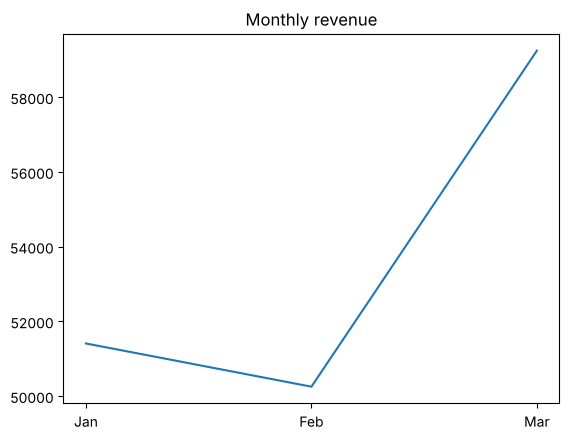

In [2]:
months = ["Jan", "Feb", "Mar"]
revenue = [51411, 50255, 59248]

plt.plot(months, revenue)
plt.title("Monthly revenue")
plt.show()

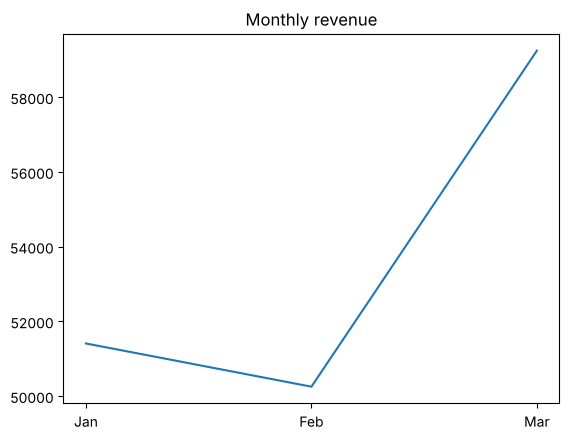

In [3]:
fig, ax = plt.subplots()
ax.plot(months, revenue)
ax.set_title("Monthly revenue")
plt.show()

In [4]:
type(fig), type(ax)

(matplotlib.figure.Figure, matplotlib.axes._axes.Axes)

### Anatomy of a figure

The next cell draws the labelled diagram used in the book. It is longer
than usual because of all the annotations; you do not need to understand
every line yet.

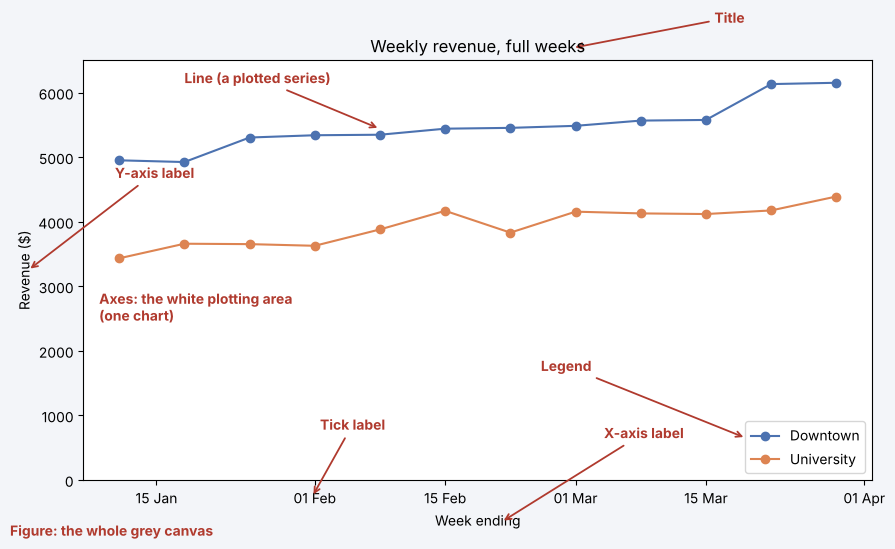

In [5]:
weekly = (
    sales.pivot_table(index="date", columns="store",
                      values="revenue", aggfunc="sum")
    .resample("W").sum()
    .iloc[1:-1]
)
fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor("#F3F5F9")
ax.plot(weekly.index, weekly["Downtown"], marker="o", color="#4C72B0",
        label="Downtown")
ax.plot(weekly.index, weekly["University"], marker="o", color="#DD8452",
        label="University")
ax.set_title("Weekly revenue, full weeks")
ax.set_xlabel("Week ending")
ax.set_ylabel("Revenue ($)")
ax.set_ylim(0, 6500)
ax.legend(loc="lower right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

note = dict(fontsize=10, color="#B03A2E", fontweight="bold")
arrow = dict(arrowstyle="->", color="#B03A2E", lw=1.3)
ax.annotate("Title", xy=(0.62, 1.03), xycoords="axes fraction",
            xytext=(0.80, 1.09), textcoords="axes fraction",
            arrowprops=arrow, **note)
ax.annotate("Line (a plotted series)", xy=(weekly.index[4], 5440),
            xytext=(weekly.index[1], 6150), arrowprops=arrow, **note)
ax.annotate("Legend", xy=(0.84, 0.10), xycoords="axes fraction",
            xytext=(0.58, 0.26), textcoords="axes fraction",
            arrowprops=arrow, **note)
ax.annotate("Y-axis label", xy=(-0.07, 0.50), xycoords="axes fraction",
            xytext=(0.04, 0.72), textcoords="axes fraction",
            arrowprops=arrow, **note)
ax.annotate("Tick label", xy=(0.29, -0.04), xycoords="axes fraction",
            xytext=(0.30, 0.12), textcoords="axes fraction",
            arrowprops=arrow, **note)
ax.annotate("X-axis label", xy=(0.53, -0.10), xycoords="axes fraction",
            xytext=(0.66, 0.10), textcoords="axes fraction",
            arrowprops=arrow, **note)
ax.text(0.02, 0.38, "Axes: the white plotting area\n(one chart)",
        transform=ax.transAxes, **note)
fig.text(0.01, 0.015, "Figure: the whole grey canvas", **note)
plt.tight_layout()
fig.savefig("../figures/ch11-anatomy.png", dpi=150,
            facecolor=fig.get_facecolor())
plt.show()

## 11.2 Line charts

In [6]:
daily = sales.pivot_table(index="date", columns="store",
                          values="revenue", aggfunc="sum")
daily.head(3)

store,Downtown,Riverside,University
date,,,
2026-01-01,696.10,310.45,568.45
2026-01-02,694.25,336.85,516.35
2026-01-03,827.75,430.85,482.55


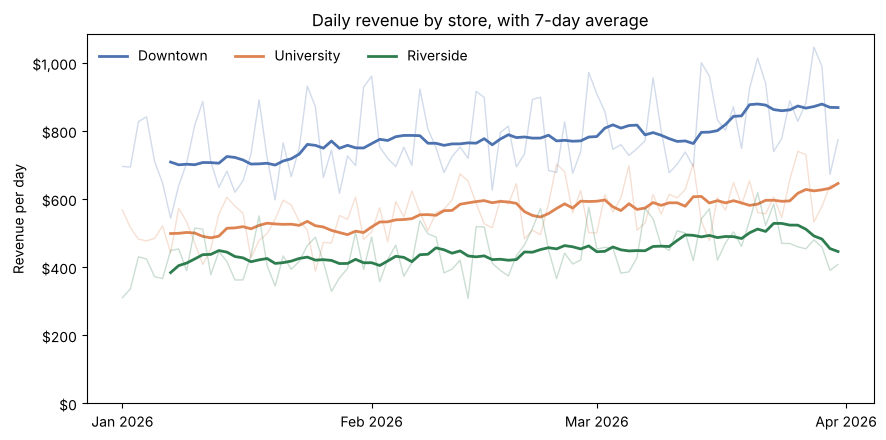

In [7]:
COLORS = {"Downtown": "#4C72B0", "University": "#DD8452",
          "Riverside": "#2E7D4F"}
smooth = daily.rolling(7).mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
for store in ["Downtown", "University", "Riverside"]:
    ax.plot(daily.index, daily[store], color=COLORS[store],
            alpha=0.25, linewidth=1)
    ax.plot(smooth.index, smooth[store], color=COLORS[store],
            linewidth=2, label=store)

ax.set_title("Daily revenue by store, with 7-day average")
ax.set_ylabel("Revenue per day")
ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_ylim(0, None)
ax.legend(loc="upper left", ncols=3, frameon=False)
plt.tight_layout()
fig.savefig("../figures/ch11-line.png", dpi=150)
plt.show()

## 11.3 Bar charts

In [8]:
by_product = (
    sales.groupby("product")["revenue"].sum().sort_values()
)
by_product

product
Blueberry Muffin    14534.65
Espresso            17715.00
Croissant           21450.00
Cold Brew           28699.50
Cappuccino          31003.75
Latte               47511.00
Name: revenue, dtype: float64

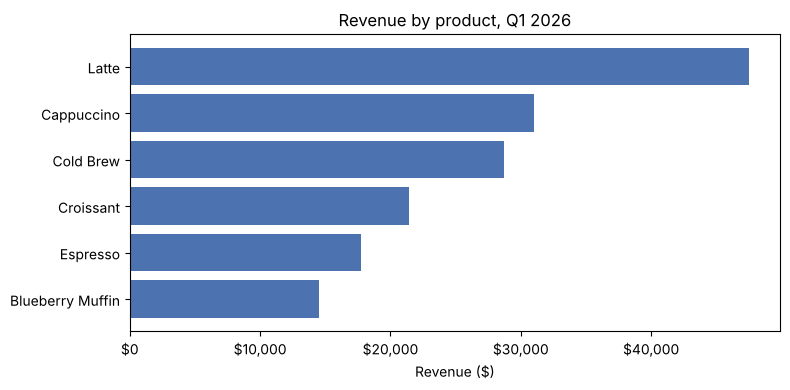

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(by_product.index, by_product.values, color="#4C72B0")
ax.set_title("Revenue by product, Q1 2026")
ax.set_xlabel("Revenue ($)")
ax.xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
plt.tight_layout()
fig.savefig("../figures/ch11-bar.png", dpi=150)
plt.show()

In [10]:
monthly = (
    sales.assign(month=sales["date"].dt.strftime("%b"))
    .pivot_table(index="month", columns="store",
                 values="revenue", aggfunc="sum")
    .loc[["Jan", "Feb", "Mar"]]
)
monthly.round(0)

store,Downtown,Riverside,University
month,,,
Jan,22626.0,12865.0,15920.0
Feb,21788.0,12421.0,16046.0
Mar,25792.0,14852.0,18604.0


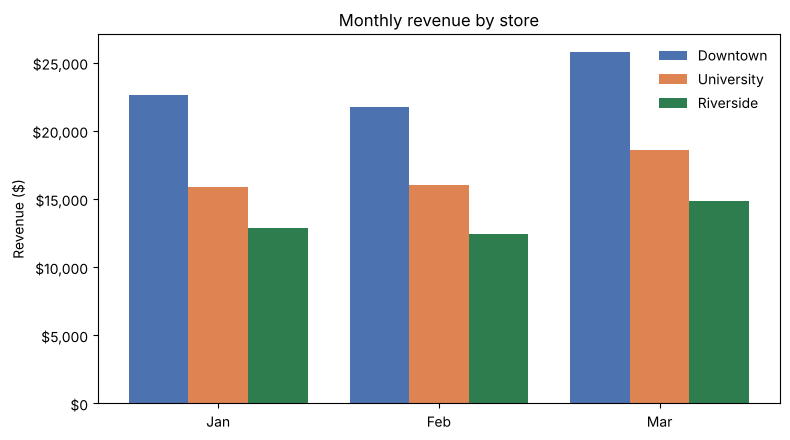

In [11]:
stores = ["Downtown", "University", "Riverside"]
x = np.arange(len(monthly))
width = 0.27

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, store in enumerate(stores):
    ax.bar(x + (i - 1) * width, monthly[store], width,
           label=store, color=COLORS[store])

ax.set_xticks(x, monthly.index)
ax.set_title("Monthly revenue by store")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
ax.legend(frameon=False)
plt.tight_layout()
fig.savefig("../figures/ch11-bar-grouped.png", dpi=150)
plt.show()

## 11.4 Scatter plots

In [12]:
tx["hour"] = tx["timestamp"].dt.hour
tx["weekend"] = tx["timestamp"].dt.dayofweek >= 5
days = np.where(tx["weekend"], 8, 20)
tx["per_day"] = 1 / days

busy = (
    tx.groupby(["store", "weekend", "hour"])
    .agg(per_hour=("per_day", "sum"),
         median_wait=("wait_min", "median"))
    .reset_index()
)
busy.head()

,store,weekend,hour,per_hour,median_wait
0,Downtown,False,6,2.00,3.35
1,Downtown,False,7,7.40,5.05
2,Downtown,False,8,12.80,9.90
3,Downtown,False,9,10.35,7.10
4,Downtown,False,10,4.50,2.85


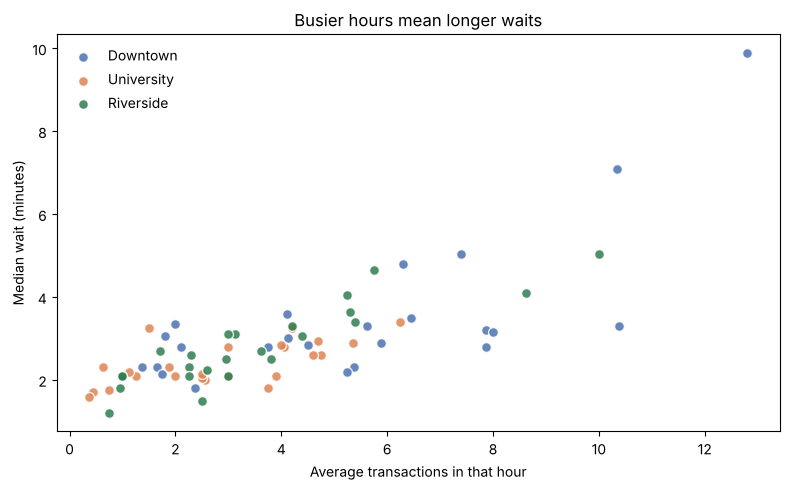

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
for store in stores:
    pts = busy[busy["store"] == store]
    ax.scatter(pts["per_hour"], pts["median_wait"], s=50,
               color=COLORS[store], label=store, alpha=0.85,
               edgecolor="white")

ax.set_title("Busier hours mean longer waits")
ax.set_xlabel("Average transactions in that hour")
ax.set_ylabel("Median wait (minutes)")
ax.legend(frameon=False)
plt.tight_layout()
fig.savefig("../figures/ch11-scatter.png", dpi=150)
plt.show()

In [14]:
busy["per_hour"].corr(busy["median_wait"]).round(2)

np.float64(0.77)

## 11.5 Histograms

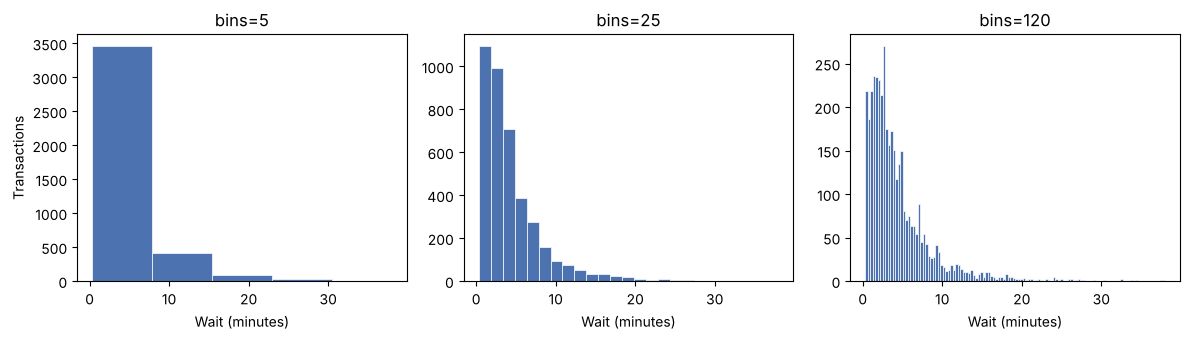

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=False)
for ax, bins in zip(axes, [5, 25, 120]):
    ax.hist(tx["wait_min"], bins=bins, color="#4C72B0",
            edgecolor="white", linewidth=0.5)
    ax.set_title(f"bins={bins}")
    ax.set_xlabel("Wait (minutes)")
axes[0].set_ylabel("Transactions")
plt.tight_layout()
fig.savefig("../figures/ch11-histogram.png", dpi=150)
plt.show()

In [16]:
counts, edges, patches = plt.hist(tx["wait_min"], bins=5)
plt.close()
print(counts)
print(edges.round(1))

[3459.  418.   91.   26.    6.]
[ 0.3  7.8 15.4 22.9 30.5 38. ]


## 11.6 Subplots

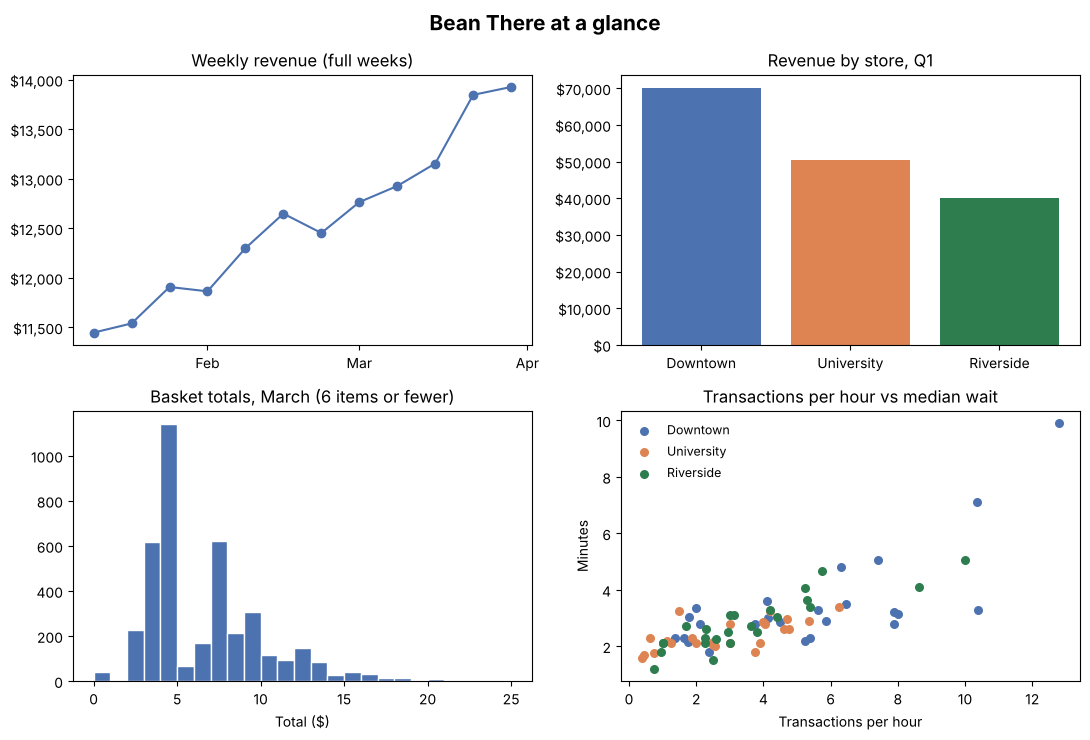

In [17]:
weekly_total = daily.sum(axis=1).resample("W").sum().iloc[1:-1]
store_rev = daily.sum().sort_values(ascending=False)
regular = tx[tx["items"] <= 6]

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))

ax = axes[0, 0]
ax.plot(weekly_total.index, weekly_total, marker="o", color="#4C72B0")
ax.set_title("Weekly revenue (full weeks)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))

ax = axes[0, 1]
ax.bar(store_rev.index, store_rev.values,
       color=[COLORS[s] for s in store_rev.index])
ax.set_title("Revenue by store, Q1")
ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))

ax = axes[1, 0]
ax.hist(regular["total"], bins=range(0, 26), color="#4C72B0",
        edgecolor="white")
ax.set_title("Basket totals, March (6 items or fewer)")
ax.set_xlabel("Total ($)")

ax = axes[1, 1]
for store in stores:
    pts = busy[busy["store"] == store]
    ax.scatter(pts["per_hour"], pts["median_wait"], s=30,
               color=COLORS[store], label=store)
ax.legend(frameon=False, fontsize=9)
ax.set_title("Transactions per hour vs median wait")
ax.set_xlabel("Transactions per hour")
ax.set_ylabel("Minutes")

fig.suptitle("Bean There at a glance", fontsize=15, fontweight="bold")
plt.tight_layout()
fig.savefig("../figures/ch11-subplots.png", dpi=150)
plt.show()

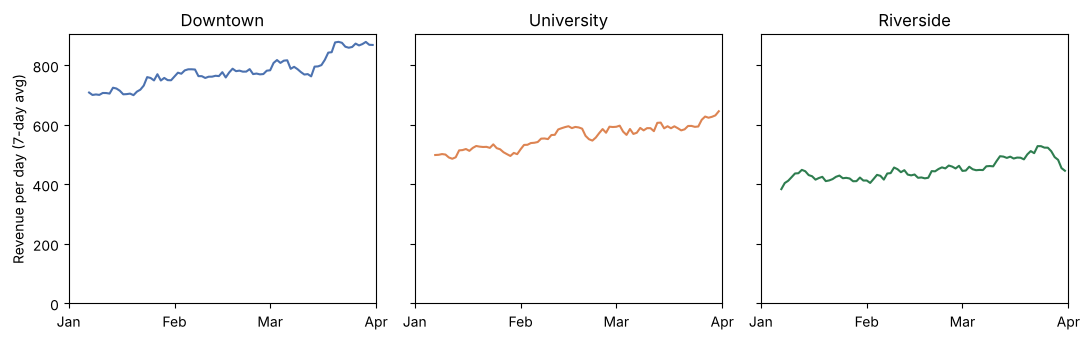

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), sharey=True)
for ax, store in zip(axes, stores):
    ax.plot(smooth.index, smooth[store], color=COLORS[store])
    ax.set_title(store)
    ax.set_xlim(pd.Timestamp("2026-01-01"), pd.Timestamp("2026-04-01"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
axes[0].set_ylabel("Revenue per day (7-day avg)")
axes[0].set_ylim(0, None)
plt.tight_layout()
fig.savefig("../figures/ch11-small-multiples.png", dpi=150)
plt.show()

## 11.7 Annotation

In [19]:
total = daily.sum(axis=1)
best_day = total.idxmax()
best_value = total.max()
print(best_day.date(), best_day.day_name(), round(best_value, 2))

2026-03-21 Saturday 2194.15


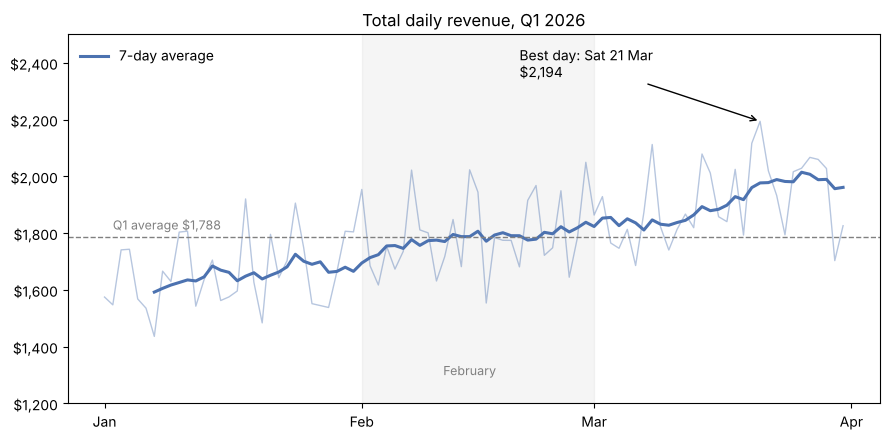

In [20]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(total.index, total, color="#4C72B0", linewidth=1, alpha=0.4)
ax.plot(total.index, total.rolling(7).mean(), color="#4C72B0",
        linewidth=2.2, label="7-day average")

avg = total.mean()
ax.axhline(avg, color="grey", linestyle="--", linewidth=1)
ax.text(total.index[1], avg + 25, f"Q1 average ${avg:,.0f}",
        color="grey", fontsize=9)

ax.axvspan(pd.Timestamp("2026-02-01"), pd.Timestamp("2026-03-01"),
           color="grey", alpha=0.08)
ax.text(pd.Timestamp("2026-02-14"), 1300, "February",
        ha="center", color="grey", fontsize=9)

ax.annotate(
    f"Best day: {best_day:%a %d %b}\n${best_value:,.0f}",
    xy=(best_day, best_value),
    xytext=(pd.Timestamp("2026-02-20"), 2350),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10,
)

ax.set_title("Total daily revenue, Q1 2026")
ax.set_ylim(1200, 2500)
ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="upper left", frameon=False)
plt.tight_layout()
fig.savefig("../figures/ch11-annotation.png", dpi=150)
plt.show()

## 11.8 Styling: before and after

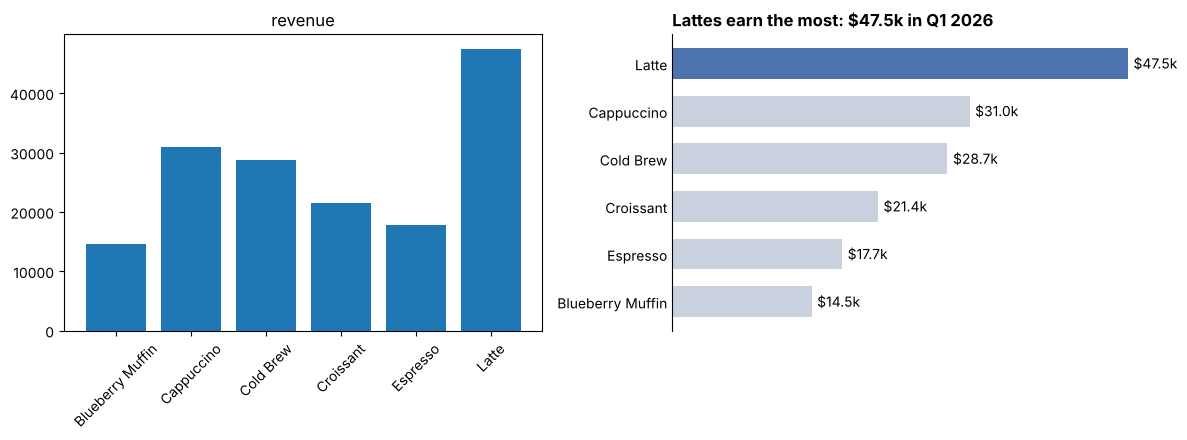

In [21]:
alpha_order = sales.groupby("product")["revenue"].sum()
top = by_product.idxmax()
bar_colors = ["#4C72B0" if p == top else "#C9D1DE"
              for p in by_product.index]

fig, (before, after) = plt.subplots(1, 2, figsize=(12, 4.5))

# Before: every default left alone
before.bar(alpha_order.index, alpha_order.values)
before.set_title("revenue")
before.tick_params(axis="x", rotation=45)

# After: sorted, highlighted, labelled, decluttered
bars = after.barh(by_product.index, by_product.values,
                  color=bar_colors, height=0.65)
after.bar_label(bars, labels=[f"${v/1000:,.1f}k" for v in by_product],
                padding=4, fontsize=10)
after.set_title("Lattes earn the most: $47.5k in Q1 2026",
                loc="left", fontsize=12, fontweight="bold")
after.spines[["top", "right", "bottom"]].set_visible(False)
after.xaxis.set_visible(False)
after.tick_params(axis="y", length=0)

plt.tight_layout()
fig.savefig("../figures/ch11-before-after.png", dpi=150)
plt.show()

In [22]:
print(len(plt.style.available), "styles, for example:")
print(plt.style.available[:5])

28 styles, for example:
['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast']


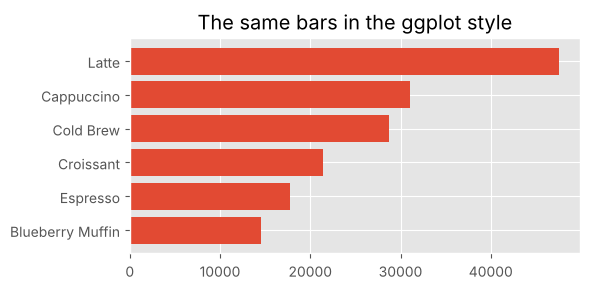

In [23]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.barh(by_product.index, by_product.values)
    ax.set_title("The same bars in the ggplot style")
    plt.tight_layout()
    fig.savefig("../figures/ch11-ggplot-style.png", dpi=150)
    plt.show()

In [24]:
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})

In [25]:
plt.rcdefaults()

## 11.9 Saving figures

In [26]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.barh(by_product.index, by_product.values, color="#4C72B0")
ax.set_title("Revenue by product, Q1 2026")
fig.savefig("revenue_by_product.png", dpi=150, bbox_inches="tight")
fig.savefig("revenue_by_product.svg", bbox_inches="tight")
plt.close(fig)

In [27]:
import os

for name in ["revenue_by_product.png", "revenue_by_product.svg"]:
    print(name, os.path.getsize(name) // 1024, "KB")
    os.remove(name)

revenue_by_product.png 26 KB
revenue_by_product.svg 27 KB


## Exercises

1. Redraw the daily line chart for **Cold Brew only**, one line per store, showing the 7-day average. Does Cold Brew grow at every store? *Hint:* filter `sales` for Cold Brew before the pivot table.
2. Turn the grouped monthly bar chart into a **stacked** bar chart. *Hint:* keep a running `bottom` array that starts at zero, pass `bottom=bottom` to `ax.bar`, and add each store's values to it after drawing.
3. Make a scatter plot of `tip` against `total` for Card and App payments with a total under $20, using `s=10` and `alpha=0.3`. What patterns do you see, and why?
4. Draw two histograms of `wait_min` on the same Axes, one for "In store" and one for "Mobile app" orders, with the same bins, `alpha=0.6` and a legend. What does the chart show?
5. Recreate the weekly revenue line from Section 11.6 on its own and use `ax.annotate` to point an arrow at its highest week, with the week's revenue in the label.
6. Apply the before/after ideas to the monthly revenue by store chart: label each bar with `ax.bar_label`, remove the y-axis and unnecessary spines, and write a title that states a finding.
7. **Think about it:** save one chart as a PNG at `dpi=300` and as an SVG, and compare the file sizes with the `dpi=150` PNG. When would you choose each?

Solutions are in Appendix D of the book.